Detected Frequency (Hz): 1.1994000000000002
Estimated Heart Rate (BPM): 71.96400000000001


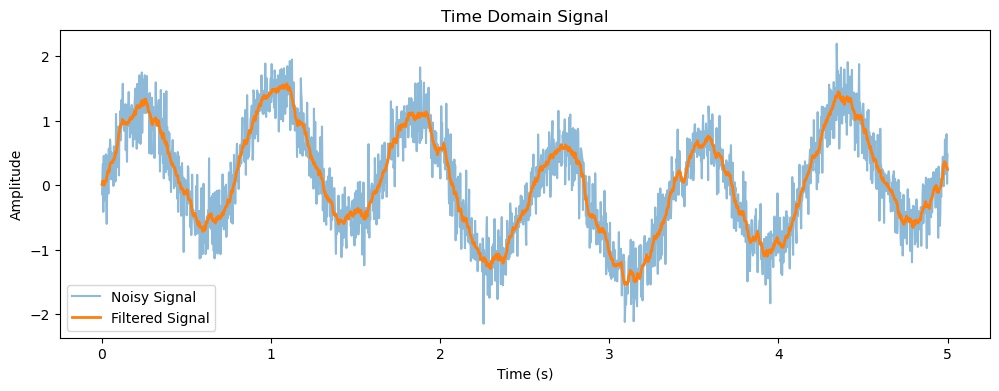

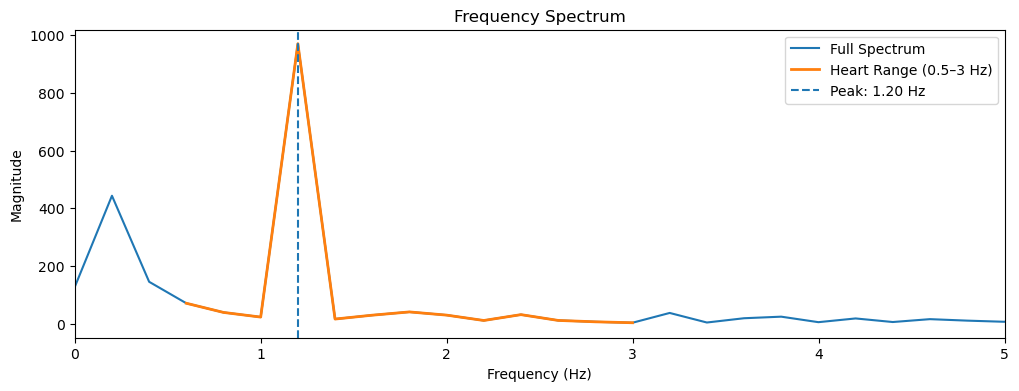

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# STEP 1: Create realistic signal
# ----------------------------
t = np.linspace(0, 5, 2000)  # 5 seconds

# Simulated biosignal:
# 1.2 Hz (~72 BPM heart) + 0.25 Hz breathing
signal = (
    np.sin(2 * np.pi * 1.2 * t) + 
    0.5 * np.sin(2 * np.pi * 0.25 * t)
)

# Add noise
noise = np.random.normal(0, 0.3, t.shape)
noisy_signal = signal + noise

# ----------------------------
# STEP 2: Filter (moving average)
# ----------------------------
window_size = 15
filtered_signal = np.convolve(
    noisy_signal,
    np.ones(window_size) / window_size,
    mode='same'
)

# ----------------------------
# STEP 3: FFT + frequency extraction
# ----------------------------
FFT = np.fft.fft(filtered_signal)
freqs = np.fft.fftfreq(len(t), t[1] - t[0])

positive_freqs = freqs[:len(freqs)//2]
positive_fft = np.abs(FFT[:len(FFT)//2])

# ----------------------------
# STEP 4: Focus on heart range (0.5–3 Hz)
# ----------------------------
mask = (positive_freqs > 0.5) & (positive_freqs < 3)

filtered_freqs = positive_freqs[mask]
filtered_fft = positive_fft[mask]

# Find peak frequency
peak_index = np.argmax(filtered_fft)
peak_frequency = filtered_freqs[peak_index]

# Convert to BPM
bpm = peak_frequency * 60

# ----------------------------
# OUTPUT
# ----------------------------
print("Detected Frequency (Hz):", peak_frequency)
print("Estimated Heart Rate (BPM):", bpm)

# ----------------------------
# PLOTS
# ----------------------------

# Time domain
plt.figure(figsize=(12,4))
plt.plot(t, noisy_signal, label="Noisy Signal", alpha=0.5)
plt.plot(t, filtered_signal, label="Filtered Signal", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Time Domain Signal")
plt.legend()
plt.show()

# Frequency domain
plt.figure(figsize=(12,4))
plt.plot(positive_freqs, positive_fft, label="Full Spectrum")
plt.plot(filtered_freqs, filtered_fft, label="Heart Range (0.5–3 Hz)", linewidth=2)
plt.axvline(peak_frequency, linestyle='--', label=f"Peak: {peak_frequency:.2f} Hz")
plt.xlim(0, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum")
plt.legend()
plt.show()